In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import lightgbm as lgb
import gc


## 1. Importing the data

In [2]:
# Load the dataset and read text files
file_path = './data/1301.txt'
data_df = pd.read_csv(file_path, delim_whitespace=True, header=0,)
data_df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_992\587305147.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_df = pd.read_csv(file_path, delim_whitespace=True, header=0,)


,Time,d90,d33,u100,u90,u80,u70,u60,u50,u40,u33
0,2013-01-01 00:00:00,228,228,16.25,15.49,14.85,14.53,14.43,13.45,12.75,12.55
1,2013-01-01 00:00:01,225,227,15.95,15.49,15.10,14.58,14.28,13.70,13.00,12.20
2,2013-01-01 00:00:02,228,227,15.65,15.84,14.85,14.68,14.53,13.75,12.45,12.55
3,2013-01-01 00:00:03,225,227,16.35,15.99,14.85,14.73,14.43,13.80,12.85,13.20
4,2013-01-01 00:00:04,225,225,16.25,16.04,15.59,15.13,14.18,13.15,13.70,13.20


In [3]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163923 entries, 0 to 2163922
Data columns (total 11 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Time    object 
 1   d90     int64  
 2   d33     int64  
 3   u100    float64
 4   u90     float64
 5   u80     float64
 6   u70     float64
 7   u60     float64
 8   u50     float64
 9   u40     float64
 10  u33     float64
dtypes: float64(8), int64(2), object(1)
memory usage: 181.6+ MB


In [4]:
data_df.shape

(2163923, 11)

In [5]:
# Find rows with invalid data (-999)
# Count -999 values in each column
print("Count of -999 values per column:")
print((data_df == -999).sum())
print("\n")

Count of -999 values per column:
Time    0
d90     0
d33     0
u100    0
u90     0
u80     0
u70     0
u60     0
u50     0
u40     0
u33     0
dtype: int64




In [6]:
# check for missing values in the dataset
print("Count of missing values per column:")
print(data_df.isnull().sum())

Count of missing values per column:
Time    0
d90     0
d33     0
u100    0
u90     0
u80     0
u70     0
u60     0
u50     0
u40     0
u33     0
dtype: int64


In [7]:
# Coverting the time column to datetime format
data_df.rename(columns={'Time': 'time'}, inplace=True)
data_df['time'] = pd.to_datetime(data_df['time'], utc=False)
data_df['time'].head()

0   2013-01-01 00:00:00
1   2013-01-01 00:00:01
2   2013-01-01 00:00:02
3   2013-01-01 00:00:03
4   2013-01-01 00:00:04
Name: time, dtype: datetime64[ns]

### 2. Generating continuous time axis.

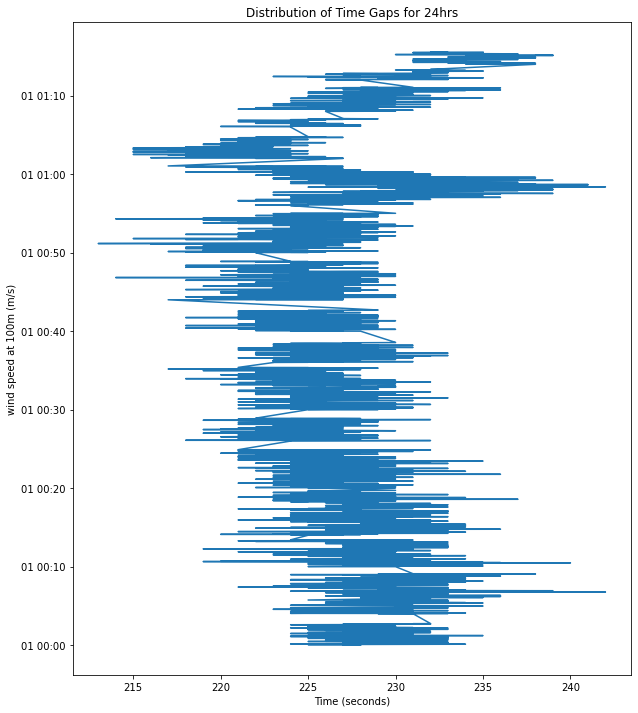

In [8]:
# Visualize gap distribution
df = data_df.iloc[:3600,2]

plt.figure(figsize=(10, 12))
plt.plot(df.iloc[:3600], data_df["time"].iloc[:3600])
plt.xlabel('Time (seconds)')
plt.ylabel('wind speed at 100m (m/s)')
plt.title('Distribution of Time Gaps for 24hrs')
plt.show()

In [9]:
# Check for gaps in the 1s sampling interval by looking at the time differences between consecutive rows
# Making sure the time column is sorted and set as index
ts_df = data_df.sort_values('time').set_index('time')

diffs = ts_df.index.to_series().diff().dt.total_seconds()
print('Number of intervals not equal to 1 second:', (diffs != 1).sum())
print('First 10 timestamps with largest gaps in seconds:')
print(diffs[diffs != 1].sort_values(ascending=False).head(10))

# Create a regular 1-second time index for the full period
full_index = pd.date_range(start=ts_df.index.min(), end=ts_df.index.max(), freq='1s')
missing = full_index.difference(ts_df.index)
print('\nMissing timestamps count:', len(missing))
print('First 10 missing timestamps:')
print(missing[:10])

# Reindex to a complete 1-second timeline and keep missing rows as NaN
# regular_ts_df = ts_df.reindex(full_index)
# regular_ts_df.head()

Number of intervals not equal to 1 second: 53234
First 10 timestamps with largest gaps in seconds:
time
2013-01-21 01:10:00    86217.0
2013-01-03 08:03:05    66923.0
2013-01-21 07:23:33    22230.0
2013-01-31 08:39:10     4021.0
2013-01-03 13:59:51     1730.0
2013-01-17 19:14:00     1499.0
2013-01-07 08:30:25     1144.0
2013-01-28 08:20:38      793.0
2013-01-24 12:44:24      689.0
2013-01-03 09:52:09      682.0
Name: time, dtype: float64

Missing timestamps count: 513886
First 10 missing timestamps:
DatetimeIndex(['2013-01-01 00:02:46', '2013-01-01 00:02:47',
               '2013-01-01 00:02:48', '2013-01-01 00:02:49',
               '2013-01-01 00:02:50', '2013-01-01 00:02:51',
               '2013-01-01 00:02:52', '2013-01-01 00:02:53',
               '2013-01-01 00:02:54', '2013-01-01 00:02:55'],
              dtype='datetime64[ns]', freq=None)


In [10]:
# 1. Ensure 'time' is a datetime object and set it as the index
data_df.reset_index(inplace=True)
data_df['time'] = pd.to_datetime(data_df['time'])
data_df = data_df.drop_duplicates(subset='time').set_index('time').sort_index()

# 2. Create the full range of expected timestamps (1-second frequency)
full_time_range = pd.date_range(
    start=data_df.index.min(), 
    end=data_df.index.max(), 
    freq='1s'
)

# 3. Reindex the DataFrame
# This automatically inserts NaNs for any missing seconds in one vectorized step
continuous_df = data_df.reindex(full_time_range)

# 4. CRITICAL FIX: Replace the "Drops" in your plot
# Based on your image, your data has drops that aren't 'missing' from the index, 
# but are 'bad' readings (zeros). We must turn these into NaNs so the model can fill them.
# We apply this only to wind speed columns (u100, u90, etc.)
#speed_cols = [col for col in continuous_df.columns if col.startswith('u')]
# continuous_df[speed_cols] = continuous_df[speed_cols].mask(continuous_df[speed_cols] < 1.0)

# 5. Clean up memory
del data_df 
import gc
gc.collect()


2892

In [11]:
continuous_df.isna().sum()

index    513886
d90      513886
d33      513886
u100     513886
u90      513886
u80      513886
u70      513886
u60      513886
u50      513886
u40      513886
u33      513886
dtype: int64

In [12]:
# # Fill NaN values using linear interpolation
# continuous_df_filled = continuous_df.interpolate(method='linear')

# print("DataFrame after linear interpolation:")
# print(continuous_df_filled.head(5))
# print("\nChecking for remaining NaNs:")
# print(continuous_df_filled.isnull().sum())

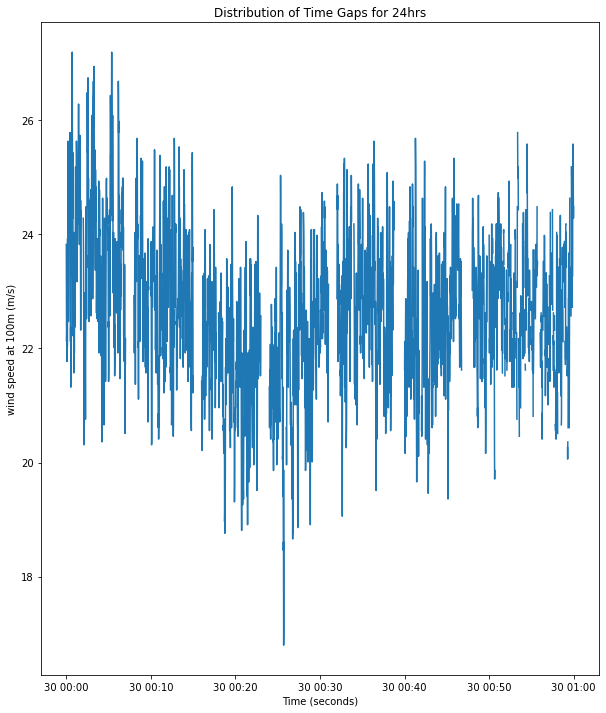

In [13]:
# Visualize gap distribution
df = continuous_df.loc['2013-01-30 00:00:00':'2013-01-30 00:59:59', :]
plt.figure(figsize=(10, 12))
plt.plot(df.index, df['u100'])
plt.xlabel('Time (seconds)')
plt.ylabel('wind speed at 100m (m/s)')
plt.title('Distribution of Time Gaps for 24hrs')
plt.show()

#### Vectorizing the wind direction measures

In [14]:
continuous_df["U90"] = np.cos(continuous_df["d90"] * np.pi/180) * continuous_df["u90"]
continuous_df["V90"] = np.sin(continuous_df["d90"] * np.pi/180) * continuous_df["u90"]
continuous_df["U33"] = np.cos(continuous_df["d33"] * np.pi/180 )* continuous_df["u33"]
continuous_df["V33"] = np.sin(continuous_df["d33"] * np.pi/180) * continuous_df["u33"]

continuous_df.head()

,index,d90,d33,u100,u90,u80,u70,u60,u50,u40,u33,U90,V90,U33,V33
2013-01-01 00:00:00,0.0,228.0,228.0,16.25,15.49,14.85,14.53,14.43,13.45,12.75,12.55,-10.364833,-11.511313,-8.397589,-9.326468
2013-01-01 00:00:01,1.0,225.0,227.0,15.95,15.49,15.10,14.58,14.28,13.70,13.00,12.20,-10.953084,-10.953084,-8.320380,-8.922515
2013-01-01 00:00:02,2.0,228.0,227.0,15.65,15.84,14.85,14.68,14.53,13.75,12.45,12.55,-10.599029,-11.771414,-8.559079,-9.178489
2013-01-01 00:00:03,3.0,225.0,227.0,16.35,15.99,14.85,14.73,14.43,13.80,12.85,13.20,-11.306637,-11.306637,-9.002378,-9.653869
2013-01-01 00:00:04,4.0,225.0,225.0,16.25,16.04,15.59,15.13,14.18,13.15,13.70,13.20,-11.341993,-11.341993,-9.333810,-9.333810


In [15]:
continuous_df = continuous_df.drop(columns=['d90', 'd33'])
continuous_df.head()

,index,u100,u90,u80,u70,u60,u50,u40,u33,U90,V90,U33,V33
2013-01-01 00:00:00,0.0,16.25,15.49,14.85,14.53,14.43,13.45,12.75,12.55,-10.364833,-11.511313,-8.397589,-9.326468
2013-01-01 00:00:01,1.0,15.95,15.49,15.10,14.58,14.28,13.70,13.00,12.20,-10.953084,-10.953084,-8.320380,-8.922515
2013-01-01 00:00:02,2.0,15.65,15.84,14.85,14.68,14.53,13.75,12.45,12.55,-10.599029,-11.771414,-8.559079,-9.178489
2013-01-01 00:00:03,3.0,16.35,15.99,14.85,14.73,14.43,13.80,12.85,13.20,-11.306637,-11.306637,-9.002378,-9.653869
2013-01-01 00:00:04,4.0,16.25,16.04,15.59,15.13,14.18,13.15,13.70,13.20,-11.341993,-11.341993,-9.333810,-9.333810


#### Dealing with Missing Values

- Since the dataset contains over 500k missing values out of around 2.6m rows of data, that's about 20% of data is missing after reindexing the timestamp to a continous 1s interval.

- Here rather than simply filling missing data with mean values, we explore to use a ML approach to learn from the data and predict the missing entries.

In [17]:

# List of all columns that need to be full
target_columns = ['u100', 'u90', 'u80', 'u70', 'u60', 'u50', 'u40', 'u33', 'U90', 'V90', 'U33', 'V33']

def impute_wind_data(df, targets):
    for target in targets:
        if df[target].isna().sum() == 0:
            continue
            
        print(f"Imputing {target}...")
        
        # Use all other columns as features
        features = [col for col in targets if col != target]
        
        # Split into training (rows where target exists) and prediction (rows where target is NaN)
        # We also need rows where features are NOT NaN to train properly
        train_df = df.dropna(subset=[target] + features)
        predict_df = df[df[target].isna()]
        
        if predict_df.empty:
            continue

        # LightGBM Regressor: Optimized for 8GB RAM
        model = lgb.LGBMRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=7,      # Limit depth to save memory
            num_leaves=31,
            n_jobs=-1,        # Use all CPU cores
            importance_type='gain'
        )
        
        model.fit(train_df[features], train_df[target])
        
        # We need to handle cases where features themselves might have NaNs in the predict_df
        # LightGBM handles NaNs in features automatically!
        preds = model.predict(predict_df[features])
        
        # Fill the gaps
        df.loc[df[target].isna(), target] = preds
        
        # Force memory cleanup
        del model, train_df, predict_df
        gc.collect()
        
    return df

# Run the imputation
df_filled = impute_wind_data(continuous_df, target_columns)

# 2. Final Physical Consistency Check
# Mathematically, u = sqrt(U^2 + V^2). 
# We override the predicted speed with the vector magnitude for d90 and d33
df_filled['u90'] = np.sqrt(df_filled['U90']**2 + df_filled['V90']**2)
df_filled['u33'] = np.sqrt(df_filled['U33']**2 + df_filled['V33']**2)

# 3. Reconstruct Directions (Degrees)
df_filled['d90'] = np.degrees(np.arctan2(df_filled['V90'], df_filled['U90'])) % 360
df_filled['d33'] = np.degrees(np.arctan2(df_filled['V33'], df_filled['U33'])) % 360

# 4. Synthesize Intermediate Directions (Veering Rate)
# Calculate the change in direction per meter of height
# We use the 'shortest path' for the angle difference to avoid 359 to 1 degree errors
def get_circular_diff(a, b):
    diff = a - b
    return (diff + 180) % 360 - 180

veering_per_meter = get_circular_diff(df_filled['d90'], df_filled['d33']) / (90 - 33)

# Apply veering to get d100, d80, d70, d60, d50, d40
heights = [100, 80, 70, 60, 50, 40]
for h in heights:
    df_filled[f'd{h}'] = (df_filled['d33'] + (h - 33) * veering_per_meter) % 360

print("Imputation Complete.")

Imputing u100...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.243980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 2163868, number of used features: 11
[LightGBM] [Info] Start training from score 10.270419
Imputing u90...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.229752 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 2163868, number of used features: 11
[LightGBM] [Info] Start training from score 9.888548
Imputing u80...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.237213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 2163868,

#### Filling the "Physical" Gaps (The other heights)
---------------------------------------------------------------------------------------------------------------------

Having recomputed a complete column for $d90$ and $d33$, we still don't have direction data for the other heights ($100, 80, 70, 60, 50, 40$). 

We use the Veering Rate approach to do this 

This is based on the physical fact that wind "twists" as it moves up the tower.

Calculate the twist per meter ($\Delta\theta$): For every single row, we calculate how many degrees the wind shifts for every meter of height between the two sensors:
$$\Delta\theta = \frac{d90 - d33}{90 - 33}$$  (Note: we must use "Circular Difference" here so that $359^\circ$ to $1^\circ$ is calculated as $2^\circ$, not $-358^\circ$) .

Estimate direction for missing heights: Since we now know the "twist rate" ($\Delta\theta$), we can then calculate the direction at any height ($X$) using the $d33$ sensor as a base: $$d_X = d33 + (X - 33) \times \Delta\theta$$ 

Example Walkthrough: Imagine at timestamp 12:00:00: $d90$ is $210^\circ$ , $d33$ is $200^\circ$
The distance between them is 57 meters.

The twist rate ($\Delta\theta$): $(210 - 200) / 57 = 0.175^\circ$ per meter.

To find the direction at 70 meters ($d70$): Height difference from the 33m sensor: $70 - 33 = 37$ meters . 
$d70$ $= 200^\circ + (37 \times 0.175^\circ) = \mathbf{206.47^\circ}$ .

In [18]:
df_filled.index.name = 'time'
df_filled.drop(columns='seconds', inplace=True, errors='ignore')
df_filled.head()

,index,u100,u90,u80,u70,u60,u50,u40,u33,U90,...,U33,V33,d90,d33,d100,d80,d70,d60,d50,d40
time,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.0,16.25,15.49,14.85,14.53,14.43,13.45,12.75,12.55,-10.364833,...,-8.397589,-9.326468,228.0,228.0,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
2013-01-01 00:00:01,1.0,15.95,15.49,15.10,14.58,14.28,13.70,13.00,12.20,-10.953084,...,-8.320380,-8.922515,225.0,227.0,224.649123,225.350877,225.701754,226.052632,226.403509,226.754386
2013-01-01 00:00:02,2.0,15.65,15.84,14.85,14.68,14.53,13.75,12.45,12.55,-10.599029,...,-8.559079,-9.178489,228.0,227.0,228.175439,227.824561,227.649123,227.473684,227.298246,227.122807
2013-01-01 00:00:03,3.0,16.35,15.99,14.85,14.73,14.43,13.80,12.85,13.20,-11.306637,...,-9.002378,-9.653869,225.0,227.0,224.649123,225.350877,225.701754,226.052632,226.403509,226.754386
2013-01-01 00:00:04,4.0,16.25,16.04,15.59,15.13,14.18,13.15,13.70,13.20,-11.341993,...,-9.333810,-9.333810,225.0,225.0,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000


In [21]:
df_filled.isna().sum()

index    513886
u100          0
u90           0
u80           0
u70           0
u60           0
u50           0
u40           0
u33           0
U90           0
V90           0
U33           0
V33           0
d90           0
d33           0
d100          0
d80           0
d70           0
d60           0
d50           0
d40           0
dtype: int64

In [ ]:
# Visualize gap distribution
df_ = df_filled.loc['2013-01-30 00:00:00':'2013-01-30 00:59:59', :]

plt.figure(figsize=(10, 12))
plt.plot(df_.index, df_['u100'])
plt.xlabel('Time (seconds)')
plt.ylabel('wind speed at 100m (m/s)')
plt.title('Distribution of Time Gaps for 24hrs')
plt.show()